# Airbnb Berlin vs Munich — Full Analysis



Berlin: 9,264 rows | Munich: 8,274 rows
After cleaning — Berlin: 9,169 | Munich: 5,545
Success rate — Berlin: 35.2% | Munich: 39.2%


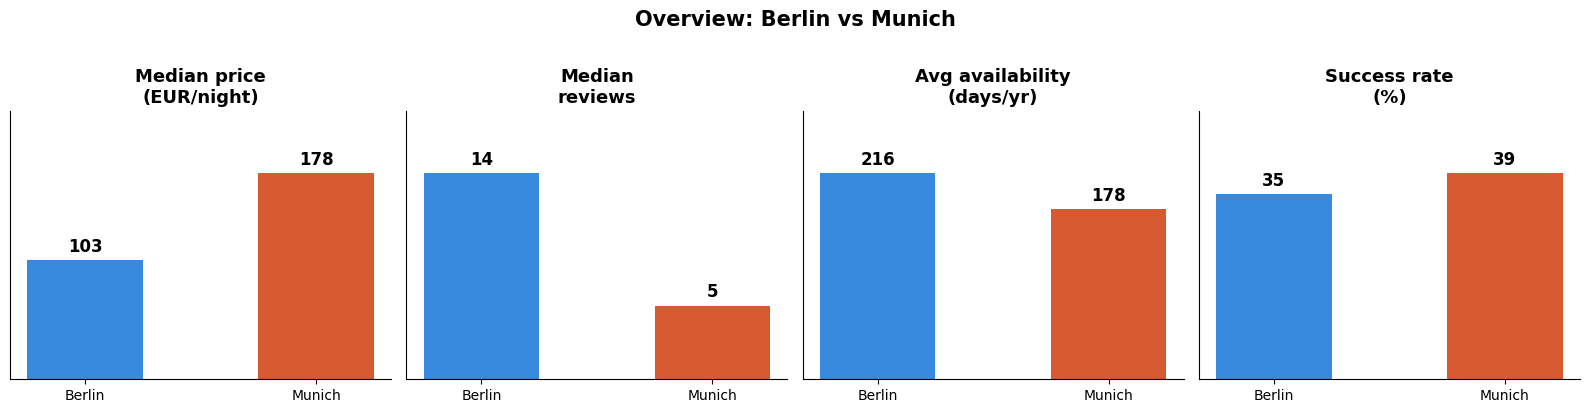

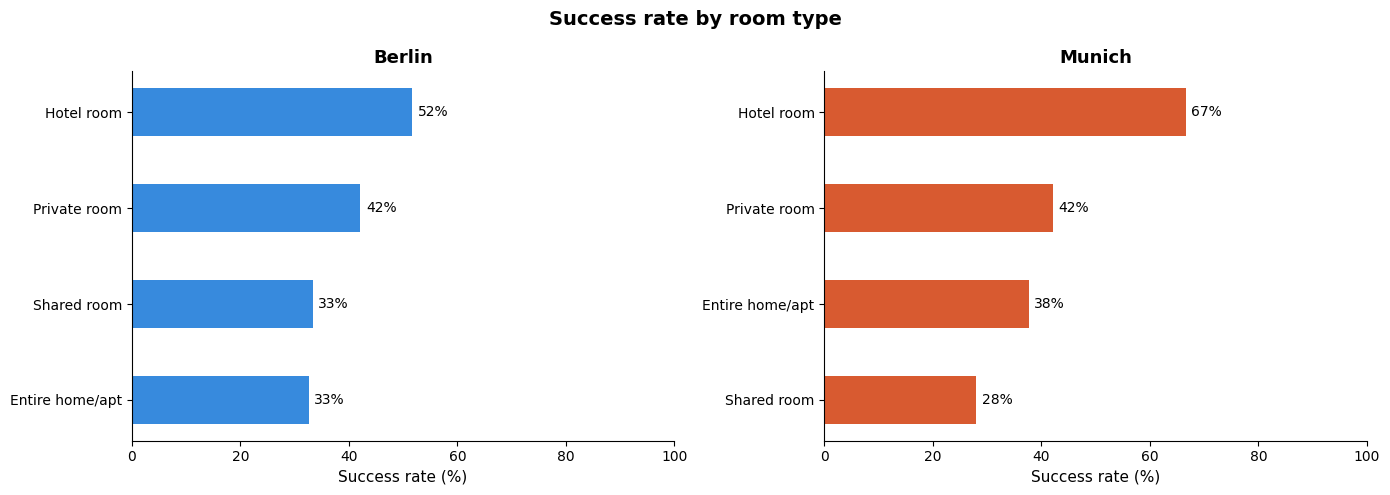

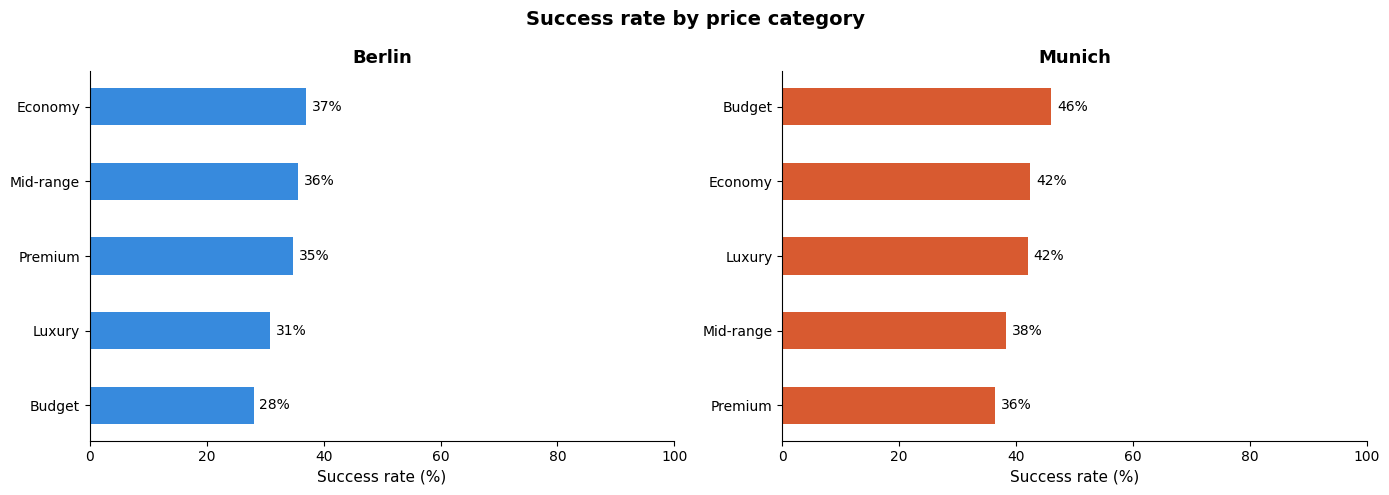

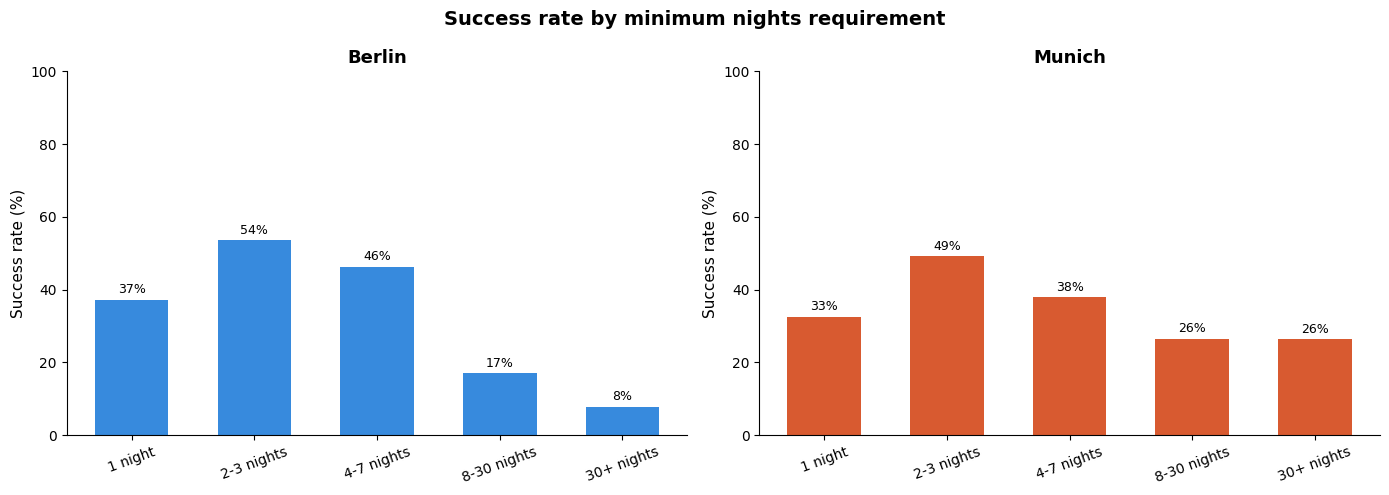

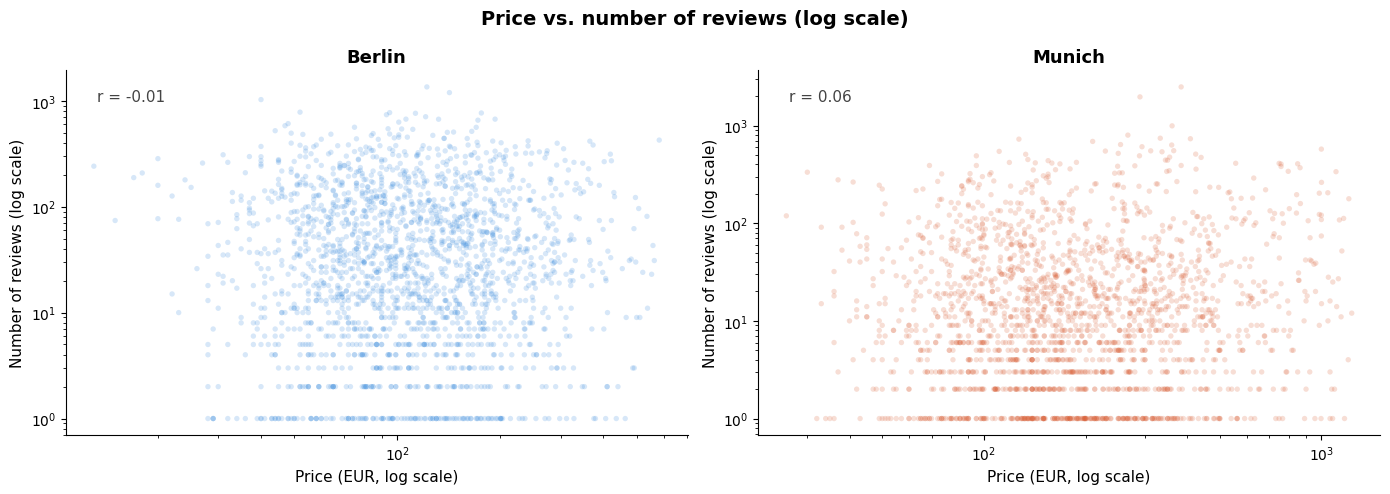

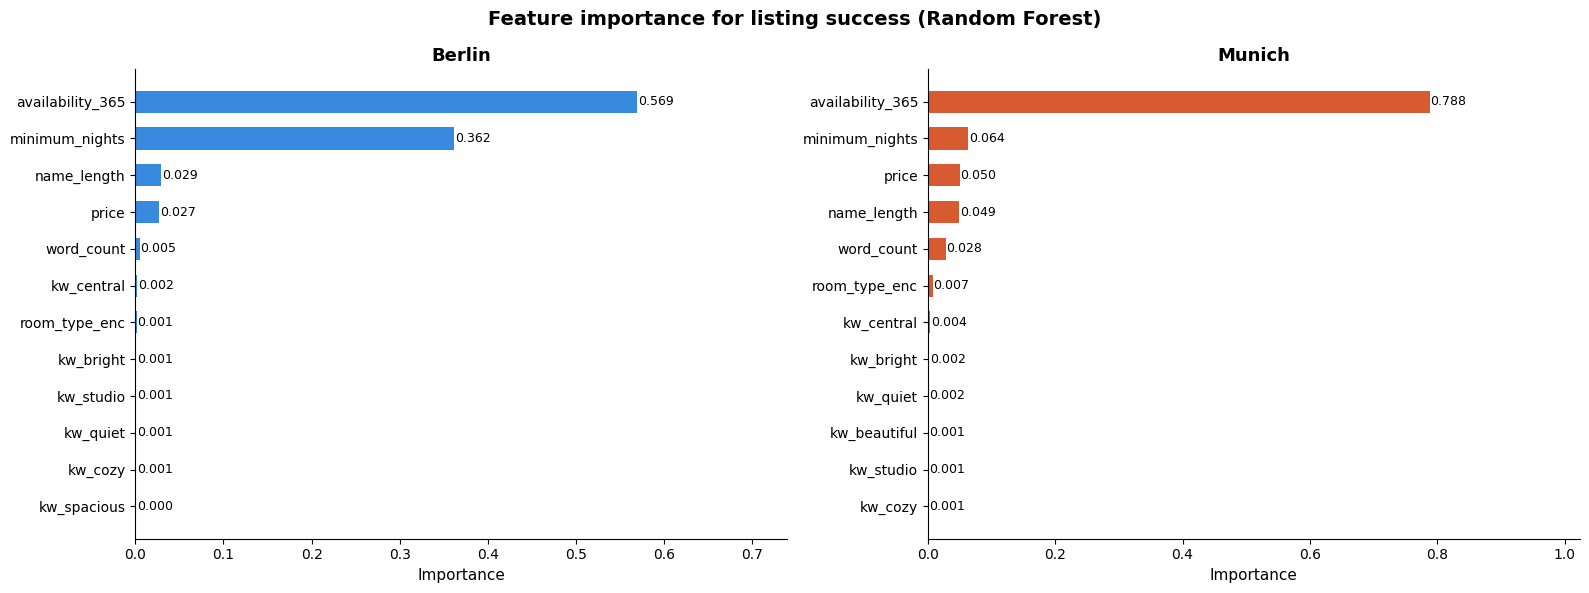

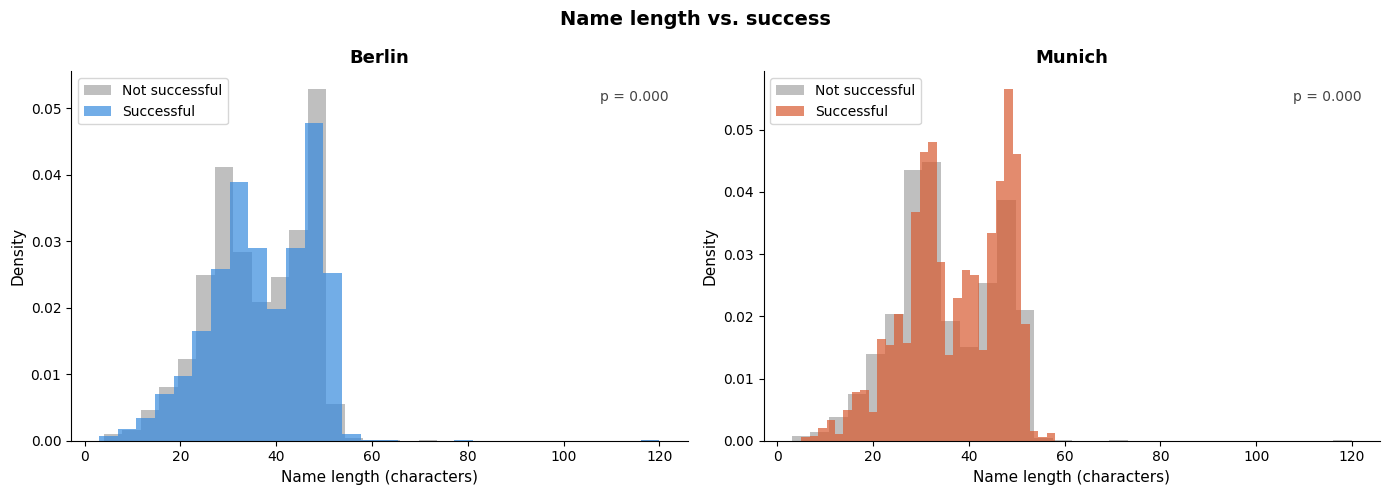

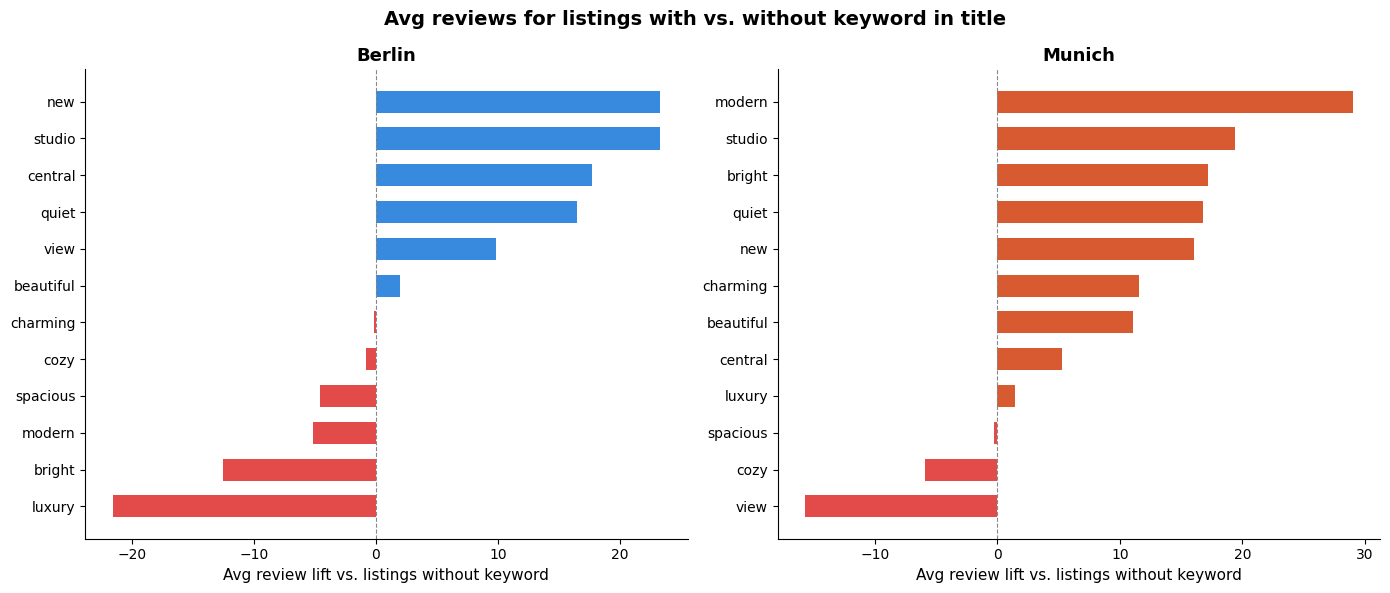

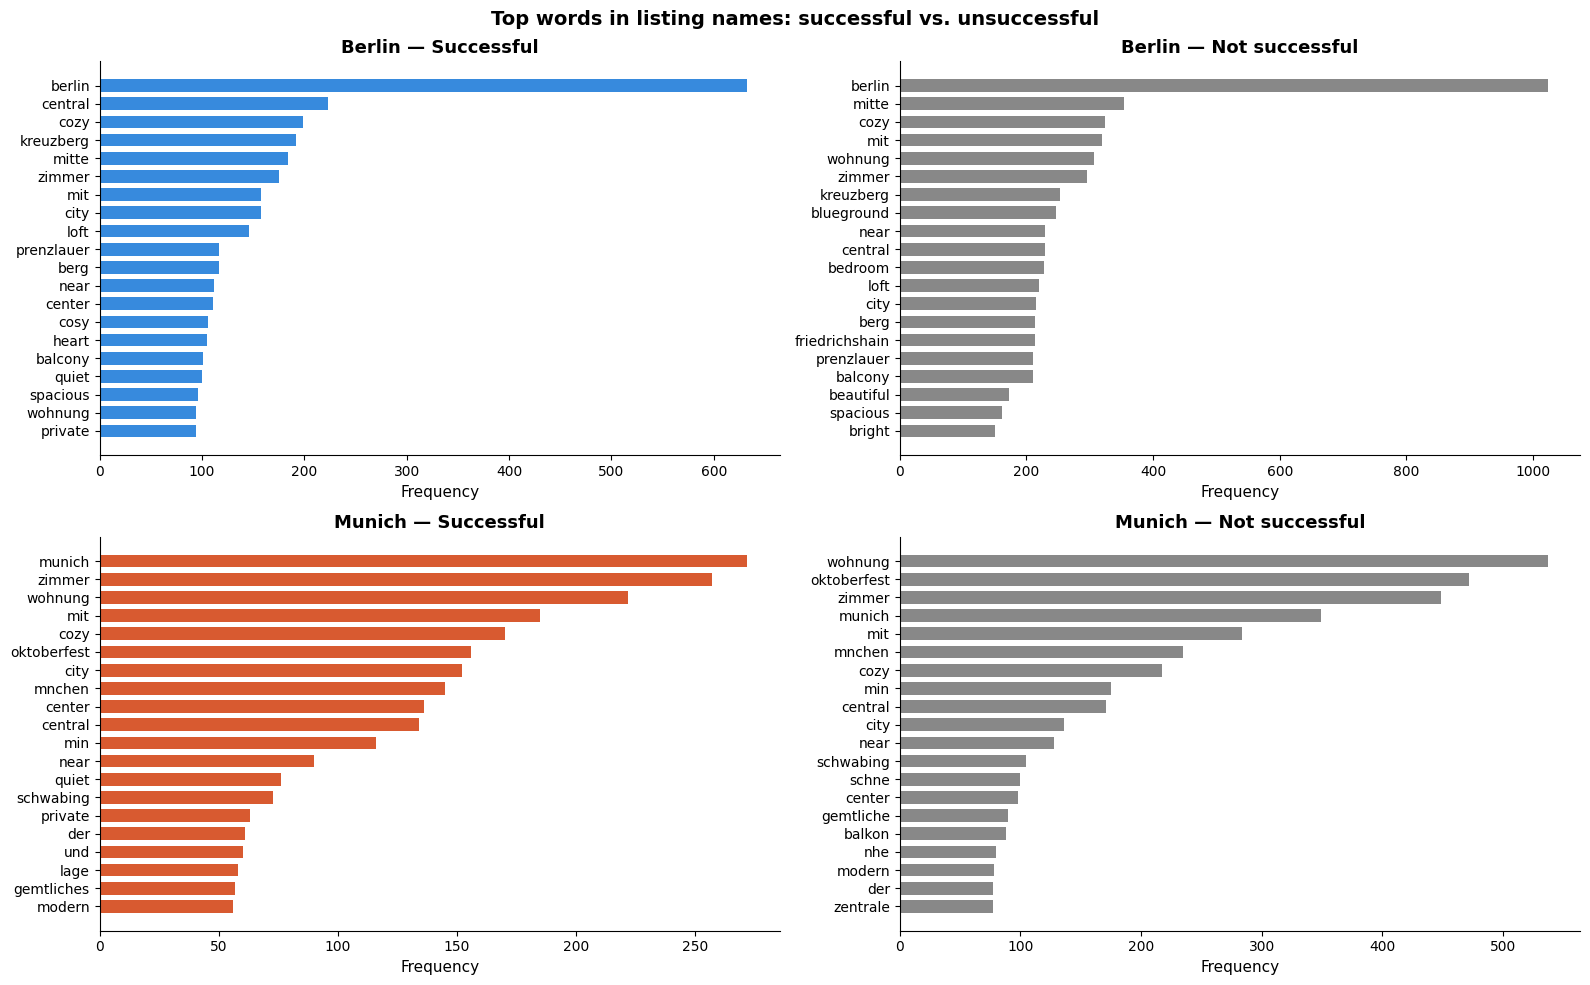

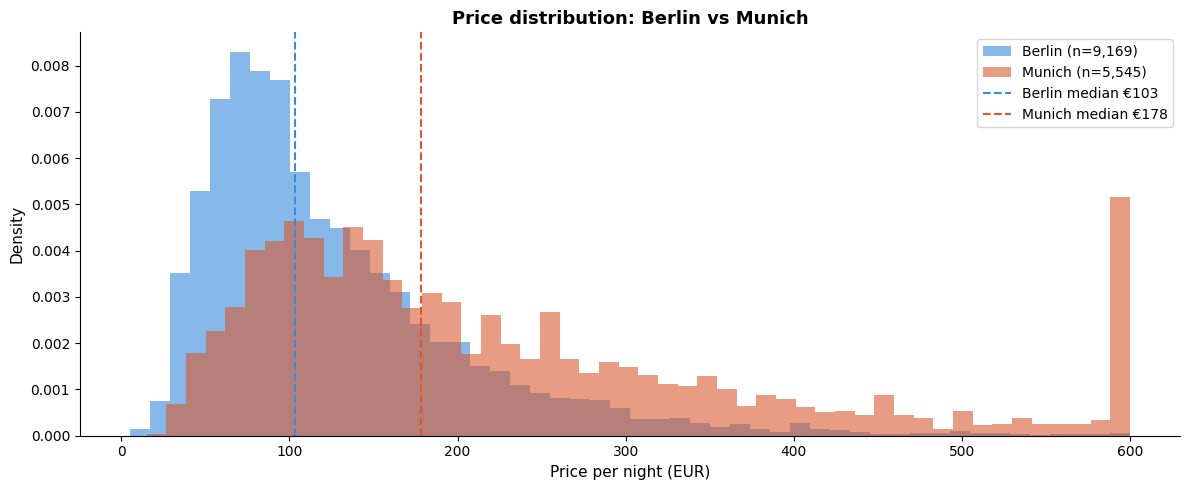

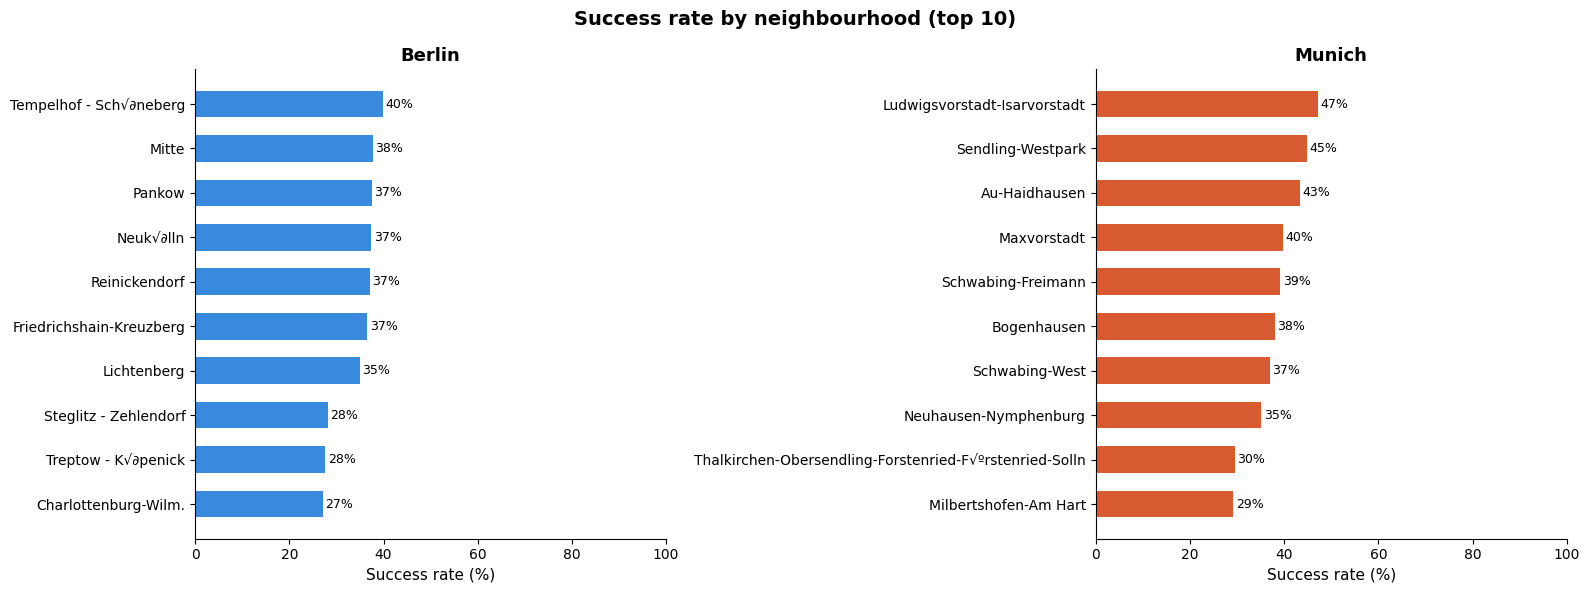

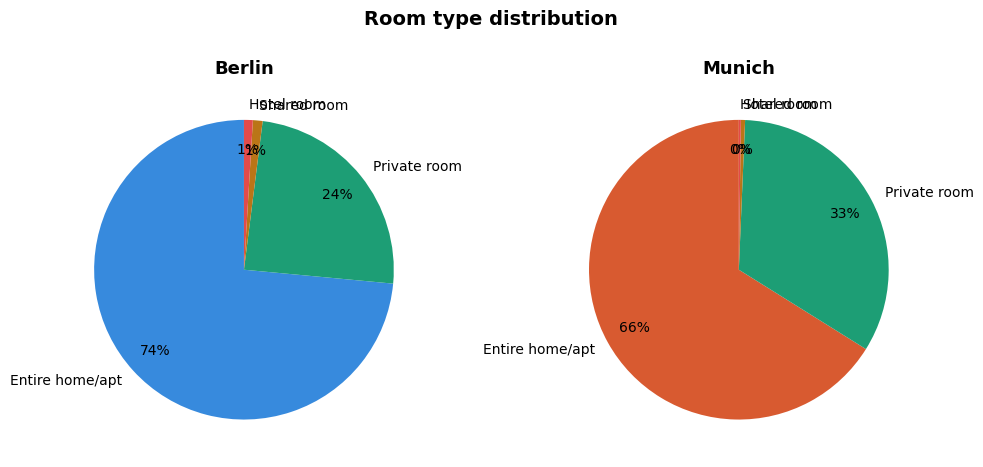

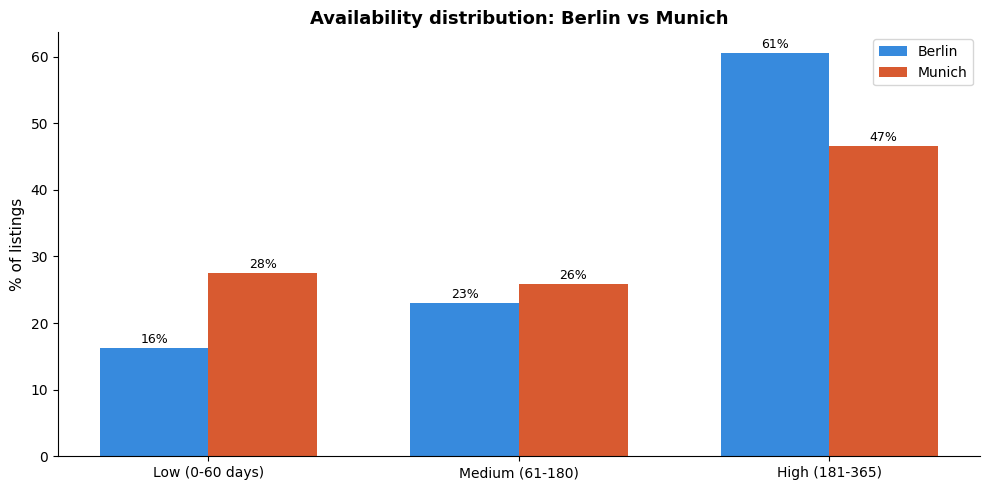

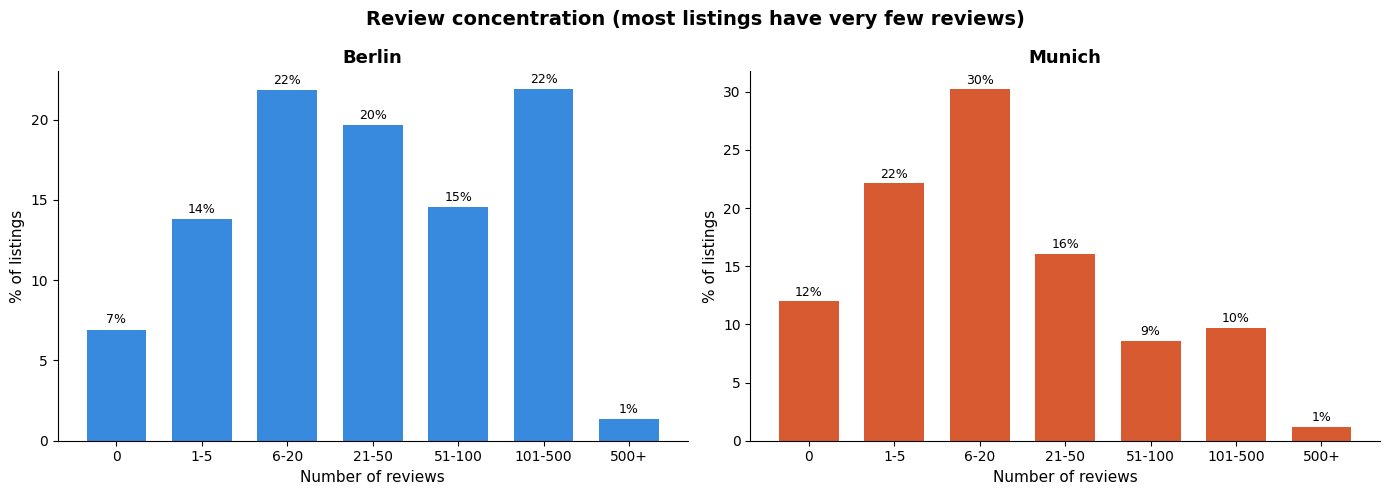

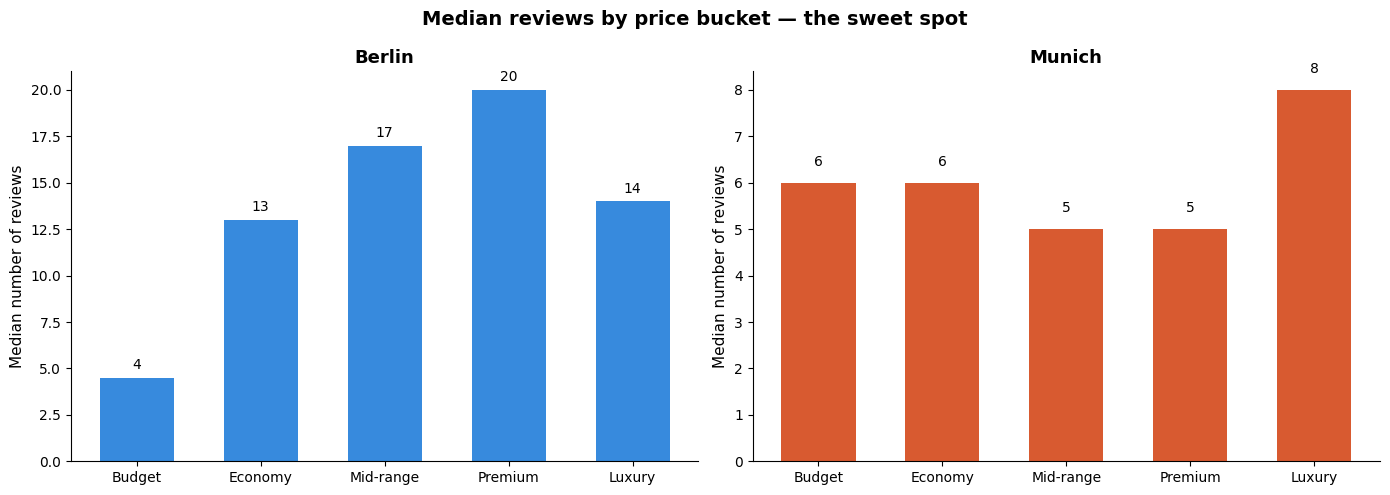


  SUMMARY: KEY DIFFERENCES BETWEEN BERLIN AND MUNICH
  Listings (cleaned)                  Berlin: 9,169        Munich: 5,545
  Median price                        Berlin: €103         Munich: €178
  Mean price                          Berlin: €126         Munich: €237
  Median reviews                      Berlin: 14           Munich: 5
  Success rate                        Berlin: 35.2%        Munich: 39.2%
  Avg availability (days)             Berlin: 216          Munich: 178
  Entire home share                   Berlin: 74%          Munich: 66%
  Median min nights                   Berlin: 3            Munich: 2

All charts saved. Download from the Files panel on the left.


In [ ]:
# ── 0. INSTALL & IMPORT ──────────────────────────────────────
!pip install openpyxl wordcloud scipy scikit-learn deep-translator -q

import zipfile, xml.etree.ElementTree as ET, re as re_mod
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from deep_translator import GoogleTranslator
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
})

BERLIN_COLOR = '#378ADD'
MUNICH_COLOR = '#D85A30'


# ── 1. LOAD FILES ────────────────────────────────────────────
def read_xlsx(filename):
    with zipfile.ZipFile(filename) as z:
        sheet_xml = z.read('xl/worksheets/sheet1.xml').decode('utf-8')
        shared_xml = z.read('xl/sharedStrings.xml').decode('utf-8')
        ns_main = re_mod.findall(r'xmlns="([^"]+)"', shared_xml)[0]
        ns = {'ns': ns_main}
        shared_tree = ET.fromstring(shared_xml)
        strings = [si.find('.//ns:t', ns) for si in shared_tree.findall('ns:si', ns)]
        strings = [s.text if s is not None else '' for s in strings]
        sheet_tree = ET.fromstring(sheet_xml)
        ns2_match = re_mod.findall(r'xmlns="([^"]+)"', sheet_xml)
        ns2 = {'ns': ns2_match[0]} if ns2_match else {}
        rows = sheet_tree.findall('.//ns:row', ns2)

        def col_idx(ref):
            ref = re_mod.sub(r'\d', '', ref)
            idx = 0
            for ch in ref:
                idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
            return idx - 1

        def cell_val(cell):
            t = cell.get('t')
            v = cell.find('ns:v', ns2)
            if v is None: return None
            if t == 's': return strings[int(v.text)]
            try: return float(v.text)
            except: return v.text

        header_row = rows[0]
        max_col = max(col_idx(c.get('r', 'A1')) for c in header_row.findall('ns:c', ns2)) + 1
        headers = [None] * max_col
        for cell in header_row.findall('ns:c', ns2):
            headers[col_idx(cell.get('r'))] = cell_val(cell)

        data = []
        for row in rows[1:]:
            row_data = [None] * max_col
            for cell in row.findall('ns:c', ns2):
                idx = col_idx(cell.get('r'))
                if idx < max_col:
                    row_data[idx] = cell_val(cell)
            data.append(row_data)

        return pd.DataFrame(data, columns=headers)

berlin = read_xlsx('Berlin listings.xlsx')
munich = read_xlsx('Munich listings.xlsx')

print(f"Berlin: {len(berlin):,} rows | Munich: {len(munich):,} rows")


# ── 2. CLEAN & ENGINEER FEATURES ─────────────────────────────
def clean_df(df, city, geo_col):
    df = df.copy()
    df['city'] = city
    df = df.rename(columns={geo_col: 'neighbourhood_group'})

    df = df.dropna(subset=['price'])
    p99 = df['price'].quantile(0.99)
    df = df[df['price'] <= p99].copy()
    df = df[df['minimum_nights'] <= 365].copy()

    df['is_successful'] = (
        (df['number_of_reviews'] > df['number_of_reviews'].median()) &
        (df['availability_365'] < 300)
    ).astype(int)

    df['price_category'] = pd.cut(df['price'],
        bins=[0, 50, 100, 200, 400, 99999],
        labels=['Budget', 'Economy', 'Mid-range', 'Premium', 'Luxury'])

    df['avail_bucket'] = pd.cut(df['availability_365'],
        bins=[-1, 60, 180, 365],
        labels=['Low (0-60)', 'Medium (61-180)', 'High (181-365)'])

    df['min_nights_cat'] = pd.cut(df['minimum_nights'],
        bins=[0, 1, 3, 7, 30, 365],
        labels=['1 night', '2-3 nights', '4-7 nights', '8-30 nights', '30+ nights'])

    df['name'] = df['name'].fillna('').astype(str)
    df['name_length'] = df['name'].str.len()
    df['word_count'] = df['name'].str.split().str.len()

    for col in ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

berlin_c = clean_df(berlin, 'Berlin', 'neighbourhood_group')
munich_c = clean_df(munich, 'Munich', 'neighbourhood')
combined = pd.concat([berlin_c, munich_c], ignore_index=True)

print(f"After cleaning — Berlin: {len(berlin_c):,} | Munich: {len(munich_c):,}")
print(f"Success rate — Berlin: {berlin_c['is_successful'].mean():.1%} | Munich: {munich_c['is_successful'].mean():.1%}")


# ── 3. TRANSLATE NAMES TO ENGLISH ────────────────────────────
def translate_batch(names, batch_size=100):
    translator = GoogleTranslator(source='auto', target='en')
    translated = []
    total = len(names)
    for i in range(0, total, batch_size):
        batch = names[i:i+batch_size]
        try:
            result = translator.translate_batch(batch)
            translated.extend(result)
        except Exception as e:
            print(f"Batch {i//batch_size} failed: {e}, using originals")
            translated.extend(batch)
        if i % 1000 == 0:
            print(f"  {min(i+batch_size, total)}/{total} translated...")
    return translated

print("Translating Berlin listing names...")
berlin_c['name_translated'] = translate_batch(berlin_c['name'].tolist())

print("Translating Munich listing names...")
munich_c['name_translated'] = translate_batch(munich_c['name'].tolist())

combined['name_translated'] = pd.concat(
    [berlin_c['name_translated'], munich_c['name_translated']], ignore_index=True
)

print("Translation done. Sample check:")
for orig, trans in zip(berlin_c['name'].head(5), berlin_c['name_translated'].head(5)):
    print(f"  '{orig}' --> '{trans}'")


# ── 4. ADD KEYWORD FEATURES (ENGLISH ONLY NOW) ───────────────
def add_keywords(df):
    name_lower = df['name_translated'].str.lower()
    df['kw_cozy']      = name_lower.str.contains(r'\bcozy\b').astype(int)
    df['kw_central']   = name_lower.str.contains(r'\bcentral\b|\bcenter\b').astype(int)
    df['kw_modern']    = name_lower.str.contains(r'\bmodern\b').astype(int)
    df['kw_luxury']    = name_lower.str.contains(r'\bluxury\b|\bluxurious\b').astype(int)
    df['kw_studio']    = name_lower.str.contains(r'\bstudio\b').astype(int)
    df['kw_spacious']  = name_lower.str.contains(r'\bspacious\b').astype(int)
    df['kw_charming']  = name_lower.str.contains(r'\bcharming\b').astype(int)
    df['kw_bright']    = name_lower.str.contains(r'\bbright\b').astype(int)
    df['kw_quiet']     = name_lower.str.contains(r'\bquiet\b').astype(int)
    df['kw_view']      = name_lower.str.contains(r'\bview\b').astype(int)
    df['kw_new']       = name_lower.str.contains(r'\bnew\b').astype(int)
    df['kw_beautiful'] = name_lower.str.contains(r'\bbeautiful\b').astype(int)
    return df

berlin_c = add_keywords(berlin_c)
munich_c = add_keywords(munich_c)
combined  = pd.concat([berlin_c, munich_c], ignore_index=True)


# ── 5. OVERVIEW ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Overview: Berlin vs Munich', fontsize=15, fontweight='bold', y=1.02)

metrics = {
    'Median price\n(EUR/night)':   [berlin_c['price'].median(), munich_c['price'].median()],
    'Median\nreviews':             [berlin_c['number_of_reviews'].median(), munich_c['number_of_reviews'].median()],
    'Avg availability\n(days/yr)': [berlin_c['availability_365'].mean(), munich_c['availability_365'].mean()],
    'Success rate\n(%)':           [berlin_c['is_successful'].mean()*100, munich_c['is_successful'].mean()*100],
}

for ax, (label, vals) in zip(axes, metrics.items()):
    bars = ax.bar(['Berlin', 'Munich'], vals, color=[BERLIN_COLOR, MUNICH_COLOR], width=0.5, edgecolor='none')
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('01_overview.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 6. SUCCESS BY ROOM TYPE ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Success rate by room type', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    st = df.groupby('room_type')['is_successful'].mean().sort_values(ascending=True) * 100
    bars = ax.barh(st.index, st.values, color=color, edgecolor='none', height=0.5)
    ax.set_xlabel('Success rate (%)')
    ax.set_title(city)
    ax.set_xlim(0, 100)
    for bar, val in zip(bars, st.values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_success_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 7. SUCCESS BY PRICE CATEGORY ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Success rate by price category', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    st = df.groupby('price_category', observed=True)['is_successful'].mean().sort_values(ascending=True) * 100
    bars = ax.barh(st.index.astype(str), st.values, color=color, edgecolor='none', height=0.5)
    ax.set_xlabel('Success rate (%)')
    ax.set_title(city)
    ax.set_xlim(0, 100)
    for bar, val in zip(bars, st.values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_success_by_price.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 8. SUCCESS BY MINIMUM NIGHTS ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Success rate by minimum nights requirement', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    st = df.groupby('min_nights_cat', observed=True)['is_successful'].mean() * 100
    bars = ax.bar(st.index.astype(str), st.values, color=color, edgecolor='none', width=0.6)
    ax.set_ylabel('Success rate (%)')
    ax.set_title(city)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, st.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('04_success_by_min_nights.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 9. PRICE vs REVIEWS SCATTER ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price vs. number of reviews (log scale)', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    sample = df[df['number_of_reviews'] > 0].sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample['price'], sample['number_of_reviews'],
               alpha=0.2, s=15, color=color, edgecolors='none')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Price (EUR, log scale)')
    ax.set_ylabel('Number of reviews (log scale)')
    ax.set_title(city)
    r, p = stats.pearsonr(np.log(sample['price']), np.log(sample['number_of_reviews']))
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=11, va='top', color='#444')

plt.tight_layout()
plt.savefig('05_price_vs_reviews.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 10. FEATURE IMPORTANCE ────────────────────────────────────
feature_cols = ['price', 'minimum_nights', 'availability_365',
                'name_length', 'word_count',
                'kw_cozy', 'kw_central', 'kw_modern', 'kw_luxury',
                'kw_studio', 'kw_spacious', 'kw_charming', 'kw_bright',
                'kw_quiet', 'kw_view', 'kw_new', 'kw_beautiful']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature importance for listing success (Random Forest)', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    le = LabelEncoder()
    df2 = df.copy()
    df2['room_type_enc'] = le.fit_transform(df2['room_type'].fillna('Unknown'))
    all_features = feature_cols + ['room_type_enc']

    X = df2[all_features].fillna(0)
    y = df2['is_successful']

    rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=True)
    top = importances.tail(12)

    bars = ax.barh(top.index, top.values, color=color, edgecolor='none', height=0.6)
    ax.set_xlabel('Importance')
    ax.set_title(city)
    ax.set_xlim(0, top.values.max() * 1.3)
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 11. NAME LENGTH vs SUCCESS ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Name length vs. success', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    success_len = df[df['is_successful'] == 1]['name_length']
    fail_len    = df[df['is_successful'] == 0]['name_length']
    ax.hist(fail_len.clip(0, 120), bins=30, alpha=0.5, color='gray', label='Not successful', density=True)
    ax.hist(success_len.clip(0, 120), bins=30, alpha=0.7, color=color, label='Successful', density=True)
    ax.set_xlabel('Name length (characters)')
    ax.set_ylabel('Density')
    ax.set_title(city)
    ax.legend()
    stat, p = stats.mannwhitneyu(success_len, fail_len, alternative='two-sided')
    ax.text(0.97, 0.95, f'p = {p:.3f}', transform=ax.transAxes, ha='right', va='top', fontsize=10, color='#444')

plt.tight_layout()
plt.savefig('07_name_length.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 12. KEYWORD IMPACT ───────────────────────────────────────
keywords = ['kw_cozy', 'kw_central', 'kw_modern', 'kw_luxury', 'kw_studio',
            'kw_spacious', 'kw_charming', 'kw_bright', 'kw_quiet', 'kw_view',
            'kw_new', 'kw_beautiful']
kw_labels = [k.replace('kw_', '') for k in keywords]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Avg reviews for listings with vs. without keyword in title (translated names)', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    diffs = []
    for kw, label in zip(keywords, kw_labels):
        with_kw    = df[df[kw] == 1]['number_of_reviews'].mean()
        without_kw = df[df[kw] == 0]['number_of_reviews'].mean()
        diffs.append({'keyword': label, 'lift': with_kw - without_kw})

    diffs_df = pd.DataFrame(diffs).sort_values('lift', ascending=True)
    colors_bar = [color if v >= 0 else '#E24B4A' for v in diffs_df['lift']]
    ax.barh(diffs_df['keyword'], diffs_df['lift'], color=colors_bar, edgecolor='none', height=0.6)
    ax.axvline(0, color='#888', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Avg review lift vs. listings without keyword')
    ax.set_title(city)

plt.tight_layout()
plt.savefig('08_keyword_impact.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 13. TOP WORDS (TRANSLATED) ───────────────────────────────
STOP_WORDS = {'a','an','the','in','at','of','for','with','and','or','to','is','this',
              'by','on','your','our','my','its','it','from','are','be','room','apartment',
              'flat','home','house','studio','1','2','3','4','5','amp','der','die','das'}

def top_words(df, n=20):
    words = []
    for name in df['name_translated'].dropna():
        for w in str(name).lower().split():
            w = re_mod.sub(r'[^a-z]', '', w)
            if w and w not in STOP_WORDS and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top words in translated listing names: successful vs. unsuccessful', fontsize=14, fontweight='bold')

for row_idx, (df, city, color) in enumerate([(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    for col_idx, (label, mask_val) in enumerate([('Successful', 1), ('Not successful', 0)]):
        ax = axes[row_idx][col_idx]
        subset = df[df['is_successful'] == mask_val]
        words = top_words(subset)
        if not words: continue
        labels_w, counts = zip(*words)
        c = color if label == 'Successful' else '#888'
        ax.barh(labels_w[::-1], counts[::-1], color=c, edgecolor='none', height=0.7)
        ax.set_title(f'{city} — {label}')
        ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('09_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 14. PRICE DISTRIBUTION ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(berlin_c['price'].clip(0, 600), bins=50, alpha=0.6, color=BERLIN_COLOR,
        label=f'Berlin (n={len(berlin_c):,})', density=True)
ax.hist(munich_c['price'].clip(0, 600), bins=50, alpha=0.6, color=MUNICH_COLOR,
        label=f'Munich (n={len(munich_c):,})', density=True)
ax.axvline(berlin_c['price'].median(), color=BERLIN_COLOR, linestyle='--', linewidth=1.5,
           label=f'Berlin median €{berlin_c["price"].median():.0f}')
ax.axvline(munich_c['price'].median(), color=MUNICH_COLOR, linestyle='--', linewidth=1.5,
           label=f'Munich median €{munich_c["price"].median():.0f}')
ax.set_xlabel('Price per night (EUR)')
ax.set_ylabel('Density')
ax.set_title('Price distribution: Berlin vs Munich')
ax.legend()
plt.tight_layout()
plt.savefig('10_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 15. SUCCESS BY NEIGHBOURHOOD ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Success rate by neighbourhood (top 10)', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    top_n = df['neighbourhood_group'].value_counts().head(10).index
    st = df[df['neighbourhood_group'].isin(top_n)].groupby('neighbourhood_group')['is_successful'].mean().sort_values() * 100
    bars = ax.barh(st.index, st.values, color=color, edgecolor='none', height=0.6)
    ax.set_xlabel('Success rate (%)')
    ax.set_title(city)
    ax.set_xlim(0, 100)
    for bar, val in zip(bars, st.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('11_success_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 16. ROOM TYPE SHARE ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Room type distribution', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    rt = df['room_type'].value_counts()
    wedge_colors = [color, '#1D9E75', '#BA7517', '#E24B4A']
    ax.pie(rt.values, labels=rt.index, autopct='%1.0f%%', colors=wedge_colors[:len(rt)],
           startangle=90, pctdistance=0.8, textprops={'fontsize': 10})
    ax.set_title(city)

plt.tight_layout()
plt.savefig('12_room_type_share.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 17. AVAILABILITY COMPARISON ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
avail_b = berlin_c['avail_bucket'].value_counts(normalize=True) * 100
avail_m = munich_c['avail_bucket'].value_counts(normalize=True) * 100
order = ['Low (0-60)', 'Medium (61-180)', 'High (181-365)']

x = np.arange(len(order))
width = 0.35
bars1 = ax.bar(x - width/2, [avail_b.get(o, 0) for o in order], width, label='Berlin', color=BERLIN_COLOR, edgecolor='none')
bars2 = ax.bar(x + width/2, [avail_m.get(o, 0) for o in order], width, label='Munich', color=MUNICH_COLOR, edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(['Low (0-60 days)', 'Medium (61-180)', 'High (181-365)'])
ax.set_ylabel('% of listings')
ax.set_title('Availability distribution: Berlin vs Munich')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('13_availability.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 18. REVIEW CONCENTRATION ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Review concentration (most listings have very few reviews)', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    review_bins = [0, 1, 5, 20, 50, 100, 500, 9999]
    labels_bins = ['0', '1-5', '6-20', '21-50', '51-100', '101-500', '500+']
    counts = pd.cut(df['number_of_reviews'], bins=review_bins, labels=labels_bins).value_counts().sort_index()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(pcts.index, pcts.values, color=color, edgecolor='none', width=0.7)
    ax.set_xlabel('Number of reviews')
    ax.set_ylabel('% of listings')
    ax.set_title(city)
    for bar, val in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.0f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('14_review_concentration.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 19. PRICE SWEET SPOT ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Median reviews by price bucket', fontsize=14, fontweight='bold')

for ax, (df, city, color) in zip(axes, [(berlin_c, 'Berlin', BERLIN_COLOR), (munich_c, 'Munich', MUNICH_COLOR)]):
    st = df.groupby('price_category', observed=True)['number_of_reviews'].median()
    bars = ax.bar(st.index.astype(str), st.values, color=color, edgecolor='none', width=0.6)
    ax.set_ylabel('Median number of reviews')
    ax.set_title(city)
    for bar, val in zip(bars, st.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.0f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('15_sweet_spot.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 20. SUMMARY ──────────────────────────────────────────────
print("\n" + "="*65)
print("  SUMMARY: KEY DIFFERENCES BETWEEN BERLIN AND MUNICH")
print("="*65)

summary = {
    'Listings (cleaned)':       [f"{len(berlin_c):,}", f"{len(munich_c):,}"],
    'Median price':             [f"€{berlin_c['price'].median():.0f}", f"€{munich_c['price'].median():.0f}"],
    'Mean price':               [f"€{berlin_c['price'].mean():.0f}", f"€{munich_c['price'].mean():.0f}"],
    'Median reviews':           [f"{berlin_c['number_of_reviews'].median():.0f}", f"{munich_c['number_of_reviews'].median():.0f}"],
    'Success rate':             [f"{berlin_c['is_successful'].mean():.1%}", f"{munich_c['is_successful'].mean():.1%}"],
    'Avg availability (days)':  [f"{berlin_c['availability_365'].mean():.0f}", f"{munich_c['availability_365'].mean():.0f}"],
    'Entire home share':        [f"{(berlin_c['room_type']=='Entire home/apt').mean():.0%}", f"{(munich_c['room_type']=='Entire home/apt').mean():.0%}"],
    'Median min nights':        [f"{berlin_c['minimum_nights'].median():.0f}", f"{munich_c['minimum_nights'].median():.0f}"],
}

for metric, (b_val, m_val) in summary.items():
    print(f"  {metric:<35} Berlin: {b_val:<12} Munich: {m_val}")

print("="*65)
print("\nAll charts saved. Download from the Files panel on the left.")